In [1]:
import matplotlib.pyplot as plt
import numpy as np
import time

def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        # Check for convergence
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k
        x = x_new
    return x, max_iterations

In [2]:
import numpy as np
import time

def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    
    for k in range(max_iterations):
        x_new = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
            
            # Check for convergence
            if np.linalg.norm(x_new - x, ord=np.inf) < tol:
                return x_new, k
        x = x_new
    return x, max_iterations

In [3]:
A = np.array([[3, -0.1, -0.2], [0.1, 7, -0.3], [0.3, -0.2, 10]])
b = np.array([7.85, -19.3, 71.4])

x0 = np.zeros_like(b)
max_iterations = 100

#Jacobi
tol = 1e-3
solution, iterations = jacobi(A, b, x0, tol, max_iterations)
print(f"Jacobi:\nTolerance: {tol}\n")
print(f"Solution: {solution}")
print(f"Iterations: {iterations}")
j3 = [solution]
tol = 1e-6
solution, iterations = jacobi(A, b, x0, tol, max_iterations)
print(f"Tolerance: {tol}\n")
print(f"Solution: {solution}")
print(f"Iterations: {iterations}")
j6 = [solution]
tol = 1e-9
solution, iterations = jacobi(A, b, x0, tol, max_iterations)
print(f"Tolerance: {tol}\n")
print(f"Solution: {solution}")
print(f"Iterations: {iterations}")
j9 = [solution]

#Gauss-Seidel
tol = 1e-3
solution, iterations = gauss_seidel(A, b, x0, tol, max_iterations)
print(f"\n\nGauss-Seidel:\n\nTolerance: {tol}\n")
print(f"Solution: {solution}")
print(f"Iterations: {iterations}")
gs3 = [solution]
tol = 1e-6
solution, iterations = gauss_seidel(A, b, x0, tol, max_iterations)
print(f"Tolerance: {tol}\n")
print(f"Solution: {solution}")
print(f"Iterations: {iterations}")
gs6 = [solution]
tol = 1e-9
solution, iterations = gauss_seidel(A, b, x0, tol, max_iterations)
print(f"Tolerance: {tol}\n")
print(f"Solution: {solution}")
print(f"Iterations: {iterations}")
gs9 = [solution]

Jacobi:
Tolerance: 0.001

Solution: [ 3.0000225  -2.50000266  6.99998104]
Iterations: 3
Tolerance: 1e-06

Solution: [ 3.  -2.5  7. ]
Iterations: 6
Tolerance: 1e-09

Solution: [ 3.  -2.5  7. ]
Iterations: 8


Gauss-Seidel:

Tolerance: 0.001

Solution: [ 3.00000035 -2.49998799  6.99999928]
Iterations: 3
Tolerance: 1e-06

Solution: [ 3.         -2.50000004  6.99999999]
Iterations: 4
Tolerance: 1e-09

Solution: [ 3.  -2.5  7. ]
Iterations: 6


In [4]:
#With the tolerance set to 10^-3, both the Jacobi and Gauss-Seidel methods only took 3 iterations to converge.
#For the trials with a tolerance of 10^-6 and 10^-9, Jacobi took 6 and 8 iterations while Gauss-Seidel took 4 and 6 respectively.

[array([ 3. , -2.5,  7. ])]
[7.3068366663875395e-06, 1.7289387699293002e-09, 1.9966250874858815e-12]
[4.239120640292526e-06, 5.650271361901105e-10, 3.197442310920451e-13]


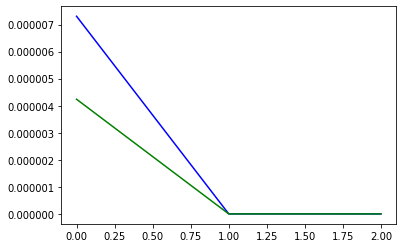

In [5]:
soeS = [3, -2.5, 7]
print(j6)
JacobiError = []
JacobiError.append(abs(np.linalg.norm(j3) - np.linalg.norm(soeS)))
JacobiError.append(abs(np.linalg.norm(j6) - np.linalg.norm(soeS)))
JacobiError.append(abs(np.linalg.norm(j9) - np.linalg.norm(soeS)))
print(JacobiError)
GaussError = []
GaussError.append(abs(np.linalg.norm(gs3) - np.linalg.norm(soeS)))
GaussError.append(abs(np.linalg.norm(gs6) - np.linalg.norm(soeS)))
GaussError.append(abs(np.linalg.norm(gs9) - np.linalg.norm(soeS)))
print(GaussError)
plt.plot(JacobiError, 'b', GaussError, 'g')
plt.show()

In [6]:
#With a decreased tolerance, error is supposedly minimized. 
#With this increase in precision, a greater number of tests is required to reach the value necessary to consider the function converged.